# 7. Synthesis

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervention </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  

# <font color="yellow">PLEASE SWITCH TO AN APPROPRIATE R KERNEL FOR THIS NOTEBOOK</font>

In [1]:
devtools::install_github("WorldWeatherAttribution/rwwa")
library(rwwa)

Using GitHub PAT from the git credential store.

Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation

Loading required package: extRemes

Loading required package: Lmoments

Loading required package: distillery


Attaching package: 'extRemes'


The following objects are masked from 'package:stats':

    qqnorm, qqplot


Loading required package: plyr


Attaching package: 'plyr'


The following object is masked from 'package:distillery':

    is.formula


Loading required package: copula

Loading required package: MASS



### <font color="orange"> User Input </font>

In [2]:
your_save_directory <- "../data"

# Synthesise results from observations and climate models

### <font color="orange"> Import Observations </font>

In [3]:
observations_file_name <- "res-obs_era5.csv"

models_file_name <- "res-models-Future-2.6.csv"

### <font color="green"> Autorun Cells </font>

In [5]:
observations_path <- file.path(your_save_directory, observations_file_name)

# load the observational results
df_obs <- read.csv(observations_path, row.names = "X")

In [6]:
df_obs

,mu0_est,mu0_lower,mu0_upper,sigma0_est,sigma0_lower,sigma0_upper,alpha_gmst_est,alpha_gmst_lower,alpha_gmst_upper,shape_est,⋯,dI_abs_upper,dI_rel_est,dI_rel_lower,dI_rel_upper,aic_est,aic_lower,aic_upper,n_est,n_lower,n_upper
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
era5,88.70773,74.11155,112.2279,35.02551,28.48205,43.34563,14.86953,-14.30867,56.5116,0.1578477,⋯,99.73876,24.34764,-16.30892,96.61639,774.4397,741.8094,796.2831,75,500,0


## Import Models

In [7]:
models_path = file.path(your_save_directory, models_file_name)

# load the climate model results
df_models <- read.csv(models_path, row.names = "X")

In [8]:
options(width = 10000)
options(max.print = 10000)
df_models

,Include,eval_sigma0_est,eval_sigma0_lower,eval_sigma0_upper,eval_shape_est,eval_shape_lower,eval_shape_upper,rp_value,attr_PR_est,attr_PR_lower,⋯,proj_dI.rel_upper,aic_eval,aic_attr,aic_proj,attr_nobs,attr_nsamp,attr_nfailed,proj_nobs,proj_nsamp,proj_nfailed
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
cccma_canesm2_clmcom_clm_cclm4_8_17,False,1.722354,1.437014,1.906026,-0.1360382,-0.3504190,-0.01410695,24.01937,2.712648,2.112300,⋯,9.184578,318.3774,318.3774,663.0630,76,10,0,151,10,0
cccma_canesm2_gerics_remo2015,True,1.394018,1.180128,1.546610,-0.2099927,-0.3440599,-0.11261795,22.10735,2.194869,1.417325,⋯,6.386286,279.4483,279.4483,555.2037,76,10,0,151,10,0
access_cm2,False,1.550926,1.339167,1.612269,-0.1746515,-0.2313086,-0.05252414,22.83256,2.938280,1.333819,⋯,7.894760,567.6344,567.6344,842.9172,146,10,0,221,10,0
canesm5,True,1.243837,1.139736,1.295533,-0.3164296,-0.4137032,-0.26084315,22.94742,4.453065,3.066471,⋯,7.656931,478.6214,478.6214,729.1136,146,10,0,221,10,0


### Filter models

In [9]:
# Should we make a little R library as well? Is this easy to include in the py library?

filter_models <- function(df, include = c("true", "false", "both")) {
    include <- match.arg(include)

    if (include == "true") {
        df <- df[df$Include == TRUE, ]
    } else if (include == "false") {
    df <- df[df$Include == FALSE, ]
    } 
    # "both" returns df unchanged

    df
}


### <font color="orange"> Filter out excluded models </font>

In [ ]:
# options: "true", "false", "both".
# "true" includes only models where Include == TRUE, "false" includes only models where Include == FALSE, "both" includes all models.
models_to_include <- "true"

### <font color="green"> Autorun Cells </font>

In [ ]:
# Maybe change the name for this column

df_models$Include <- as.logical(df_models$Include)
# Only models with Include == TRUE
df_models <- filter_models(df_models, models_to_include)

In [11]:
df_models

,Include,eval_sigma0_est,eval_sigma0_lower,eval_sigma0_upper,eval_shape_est,eval_shape_lower,eval_shape_upper,rp_value,attr_PR_est,attr_PR_lower,⋯,proj_dI.rel_upper,aic_eval,aic_attr,aic_proj,attr_nobs,attr_nsamp,attr_nfailed,proj_nobs,proj_nsamp,proj_nfailed
,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
cccma_canesm2_gerics_remo2015,TRUE,1.394018,1.180128,1.546610,-0.2099927,-0.3440599,-0.1126180,22.10735,2.194869,1.417325,⋯,6.386286,279.4483,279.4483,555.2037,76,10,0,151,10,0
canesm5,TRUE,1.243837,1.139736,1.295533,-0.3164296,-0.4137032,-0.2608431,22.94742,4.453065,3.066471,⋯,7.656931,478.6214,478.6214,729.1136,146,10,0,221,10,0


## Calculate Synthesis

### <font color="orange"> Choose Synthesis Type </font>

In [12]:
# if looking at temperature data / 'shift' fit, use "abs";
# if looking at precipitation / 'fixeddisp', use "rel";
# use PR for probability ratio
synthesis_type <- "abs"

### <font color="green"> Autorun Cells </font>

In [13]:
# change in intensity from past-present
synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type), colnames(df_obs))], 
                           models_in = df_models[,grepl(paste0("attr_dI.", synthesis_type), colnames(df_models))], 
                           synth_type = synthesis_type)
synth_dI_attr
# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these

group,model,est,lower,upper,l_wb,u_wb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,era5,39.743605,-39.5573765,99.738761,-39.5573765,99.738761
obs_synth,Observations,39.743605,-39.5573765,99.738761,NA,NA
models,cccma_canesm2_gerics_remo2015,1.236046,0.6592519,2.022262,0.6592519,2.022262
models,canesm5,1.613586,1.2681126,1.913421,1.2681126,1.913421
model_synth,Models,1.544456,1.1464416,1.976456,NA,NA
synth,Synthesis,1.545812,0.9280080,2.106536,-35.4309376,63.068112


In [14]:

# change in likelihood from past-present (if there are any infinite values in the PRs, replace them with estimated values)
synth_PR_attr <- synthesis(obs_in = infer_infinite(df_obs[,grepl("PR", colnames(df_obs))]), 
                           models_in = infer_infinite(df_models[,grepl("attr_PR", colnames(df_models))]), 
                           synth_type = "PR")
synth_PR_attr
# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these

group,model,est,lower,upper,l_wb,u_wb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,era5,2.335508,0.1425413,10.128937,0.1425413,10.128937
obs_synth,Observations,2.335508,0.1425413,10.128937,NA,NA
models,cccma_canesm2_gerics_remo2015,2.194869,1.4173249,5.255156,0.9105923,6.999743
models,canesm5,4.453065,3.0664706,10.024327,1.9039575,13.567272
model_synth,Models,3.171298,1.3362911,9.878467,NA,NA
synth,Synthesis,3.000999,0.7236912,9.990429,0.3435519,10.108257


In [15]:
# change in intensity from present-future
synth_dI_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl(paste0("proj_dI.", synthesis_type), colnames(df_models))], 
                           synth_type = synthesis_type)
synth_dI_proj

,group,model,est,lower,upper,l_wb,u_wb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,models,cccma_canesm2_gerics_remo2015,1.299453,1.2209952,1.496930,0.5331839,2.08686
4,models,canesm5,1.859584,1.7918212,1.928568,1.0943358,2.62494
5,model_synth,Models,1.582910,0.8171576,2.359237,NA,NA


In [16]:
# change in likelihood from present-future
synth_PR_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl("proj_PR", colnames(df_models))], 
                           synth_type = "PR")
synth_PR_proj

,group,model,est,lower,upper,l_wb,u_wb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,models,cccma_canesm2_gerics_remo2015,1.528803,1.495352,1.625575,1.331977,1.774863
4,models,canesm5,1.694971,1.670828,1.708093,1.478278,1.942386
5,model_synth,Models,1.613212,1.406274,1.860507,NA,NA


### Combine synthesis results into table

In [17]:
# function for extracting the correct rows from the synthesis

extract_row <- function(df, group, best = TRUE, use_wb = FALSE) {
  row <- df[df$group == group, ]

  data.frame(
    best = if (best) row$est else NA_real_,
    low  = if (use_wb) row$l_wb else row$lower,
    high = if (use_wb) row$u_wb else row$upper
  )
}


In [ ]:
# extract rows and combine into new table

obs_PR <- extract_row(synth_PR_attr$df, "obs_synth")
obs_dI <- extract_row(synth_dI_attr$df, "obs_synth")

model_PR <- extract_row(synth_PR_attr$df, "model_synth")
model_dI <- extract_row(synth_dI_attr$df, "model_synth")

syn_w_PR <- extract_row(synth_PR_attr$df, "synth")
syn_w_dI <- extract_row(synth_dI_attr$df, "synth")

syn_uw_PR <- extract_row(synth_PR_attr$df, "synth", best = FALSE, use_wb = TRUE)
syn_uw_dI <- extract_row(synth_dI_attr$df, "synth", best = FALSE, use_wb = TRUE)

model_f_PR <- extract_row(synth_PR_proj$df, "model_synth")
model_f_dI <- extract_row(synth_dI_proj$df, "model_synth")

# combine results into new table
synth_comb <- rbind(
  obs = cbind(PR = obs_PR, dI = obs_dI),
  model = cbind(PR = model_PR, dI = model_dI),
  `synthesis weighted` = cbind(PR = syn_w_PR, dI = syn_w_dI),
  `synthesis unweighted` = cbind(PR = syn_uw_PR, dI = syn_uw_dI),
  `model future` = cbind(PR = model_f_PR, dI = model_f_dI)
)

colnames(synth_comb) <- c(
  "PR best", "PR low", "PR high",
  "dI best", "dI low", "dI high"
)

# set the 'best' values for the unweighted synthesis
synth_comb["synthesis unweighted", "PR best"] <- synth_PR_attr$uw_mean
synth_comb["synthesis unweighted", "dI best"] <- synth_dI_attr$uw_mean

synth_comb

,PR best,PR low,PR high,dI best,dI low,dI high
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,2.335508,0.1425413,10.128937,39.743605,-39.5573765,99.738761
model,3.171298,1.3362911,9.878467,1.544456,1.1464416,1.976456
synthesis weighted,3.000999,0.7236912,9.990429,1.545812,0.9280080,2.106536
synthesis unweighted,2.721506,0.3435519,10.108257,20.644031,-35.4309376,63.068112
model future,1.613212,1.4062741,1.860507,1.582910,0.8171576,2.359237


### <font color="orange"> Optionally Use Different Filenames </font>

In [19]:
# save all the synthesised results
write.csv(synth_dI_attr$df, file.path(your_save_directory, "synth_dI_attr.csv"))
write.csv(synth_PR_attr$df, file.path(your_save_directory, ".synth_PR_attr.csv"))
write.csv(synth_dI_proj$df, file.path(your_save_directory, "synth_dI_proj.csv"))
write.csv(synth_PR_proj$df, file.path(your_save_directory, "synth_PR_proj.csv"))
write.csv(synth_comb, file.path(your_save_directory, "synth_comb.csv"))

## Optionally calculate the inverse PR

### Observations

In [20]:
# Select columns containing "PR_"
df_obs_inverse_pr  <- df_obs[, grepl("PR_", names(df_obs)), drop = FALSE]

# Invert values (1 / value)
df_obs_inverse_pr[] <- 1 / df_obs_inverse_pr

df_obs_inverse_pr

,PR_est,PR_lower,PR_upper
,<dbl>,<dbl>,<dbl>
era5,0.4281723,7.015512,0.09872704


### Models

In [21]:
# Select columns containing "PR_"
df_models_inverse_pr  <- df_models[, grepl("PR_", names(df_models)), drop = FALSE]

# Invert values (1 / value)
df_models_inverse_pr[] <- 1 / df_models_inverse_pr

df_models_inverse_pr

,attr_PR_est,attr_PR_lower,attr_PR_upper,proj_PR_est,proj_PR_lower,proj_PR_upper
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cccma_canesm2_gerics_remo2015,0.4556081,0.7055545,0.19028931,0.6541066,0.6687389,0.6151671
canesm5,0.2245644,0.3261078,0.09975732,0.5899805,0.5985056,0.5854483


### Synthesis Attributes

In [22]:
synth_PR_attr_inverse_pr <- synth_PR_attr$df

num_cols <- sapply(synth_PR_attr_inverse_pr, is.numeric)

synth_PR_attr_inverse_pr[, num_cols] <- 1 / synth_PR_attr_inverse_pr[, num_cols]

synth_PR_attr_inverse_pr


group,model,est,lower,upper,l_wb,u_wb
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
obs,era5,0.4281723,7.0155120,0.09872704,7.0155120,0.09872704
obs_synth,Observations,0.4281723,7.0155120,0.09872704,NA,NA
models,cccma_canesm2_gerics_remo2015,0.4556081,0.7055545,0.19028931,1.0981863,0.14286240
models,canesm5,0.2245644,0.3261078,0.09975732,0.5252218,0.07370679
model_synth,Models,0.3153283,0.7483399,0.10123028,NA,NA
synth,Synthesis,0.3332223,1.3818048,0.10009580,2.9107682,0.09892903


### Synthesis Projection

In [23]:
synth_PR_proj_inverse_pr <- synth_PR_proj$df

num_cols <- sapply(synth_PR_proj_inverse_pr, is.numeric)

synth_PR_proj_inverse_pr[, num_cols] <- 1 / synth_PR_proj_inverse_pr[, num_cols]

synth_PR_proj_inverse_pr

,group,model,est,lower,upper,l_wb,u_wb
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,models,cccma_canesm2_gerics_remo2015,0.6541066,0.6687389,0.6151671,0.7507635,0.5634238
4,models,canesm5,0.5899805,0.5985056,0.5854483,0.6764625,0.5148307
5,model_synth,Models,0.6198814,0.7110989,0.5374880,NA,NA


## Synthesis figures

### Optionally remove models from probability if all values are INF



In [24]:
# Models that have al inf values for PR should be excluded from the probability ratio but should be included in the intensity
remove_inf <- TRUE

if (remove_inf) {

  synth_PR_attr$df <- synth_PR_attr$df[
    !is.infinite(synth_PR_attr$df$est) &
    !is.infinite(synth_PR_attr$df$lower),
  ]

  synth_PR_proj$df <- synth_PR_proj$df[
    !is.infinite(synth_PR_proj$df$est) &
    !is.infinite(synth_PR_proj$df$lower),
  ]
}

In [25]:
prep_rc = c(1, 2)
prep_h = 5                      # height of the figure (ins)
prep_w = 5                      # width of the figure (ins)
prep_res = 200
prep_pch = 20
prep_oma = c(0, 14, 0, 0)       # increase second number until model names fit in margin
prep_mar = c(3, .5, 2, .5)      # shouldn't need to be changed

# Change until the bars fit the plot
x_lim_dI <- range(
  synth_dI_attr$df[sapply(synth_dI_attr$df, is.numeric)],
  na.rm = TRUE
) * 1.1
x_lim_PR = range(
  synth_PR_attr$df[sapply(synth_PR_attr$df, is.numeric)],
  na.rm = TRUE
) * 1.1 # add some padding to the x-axis limits

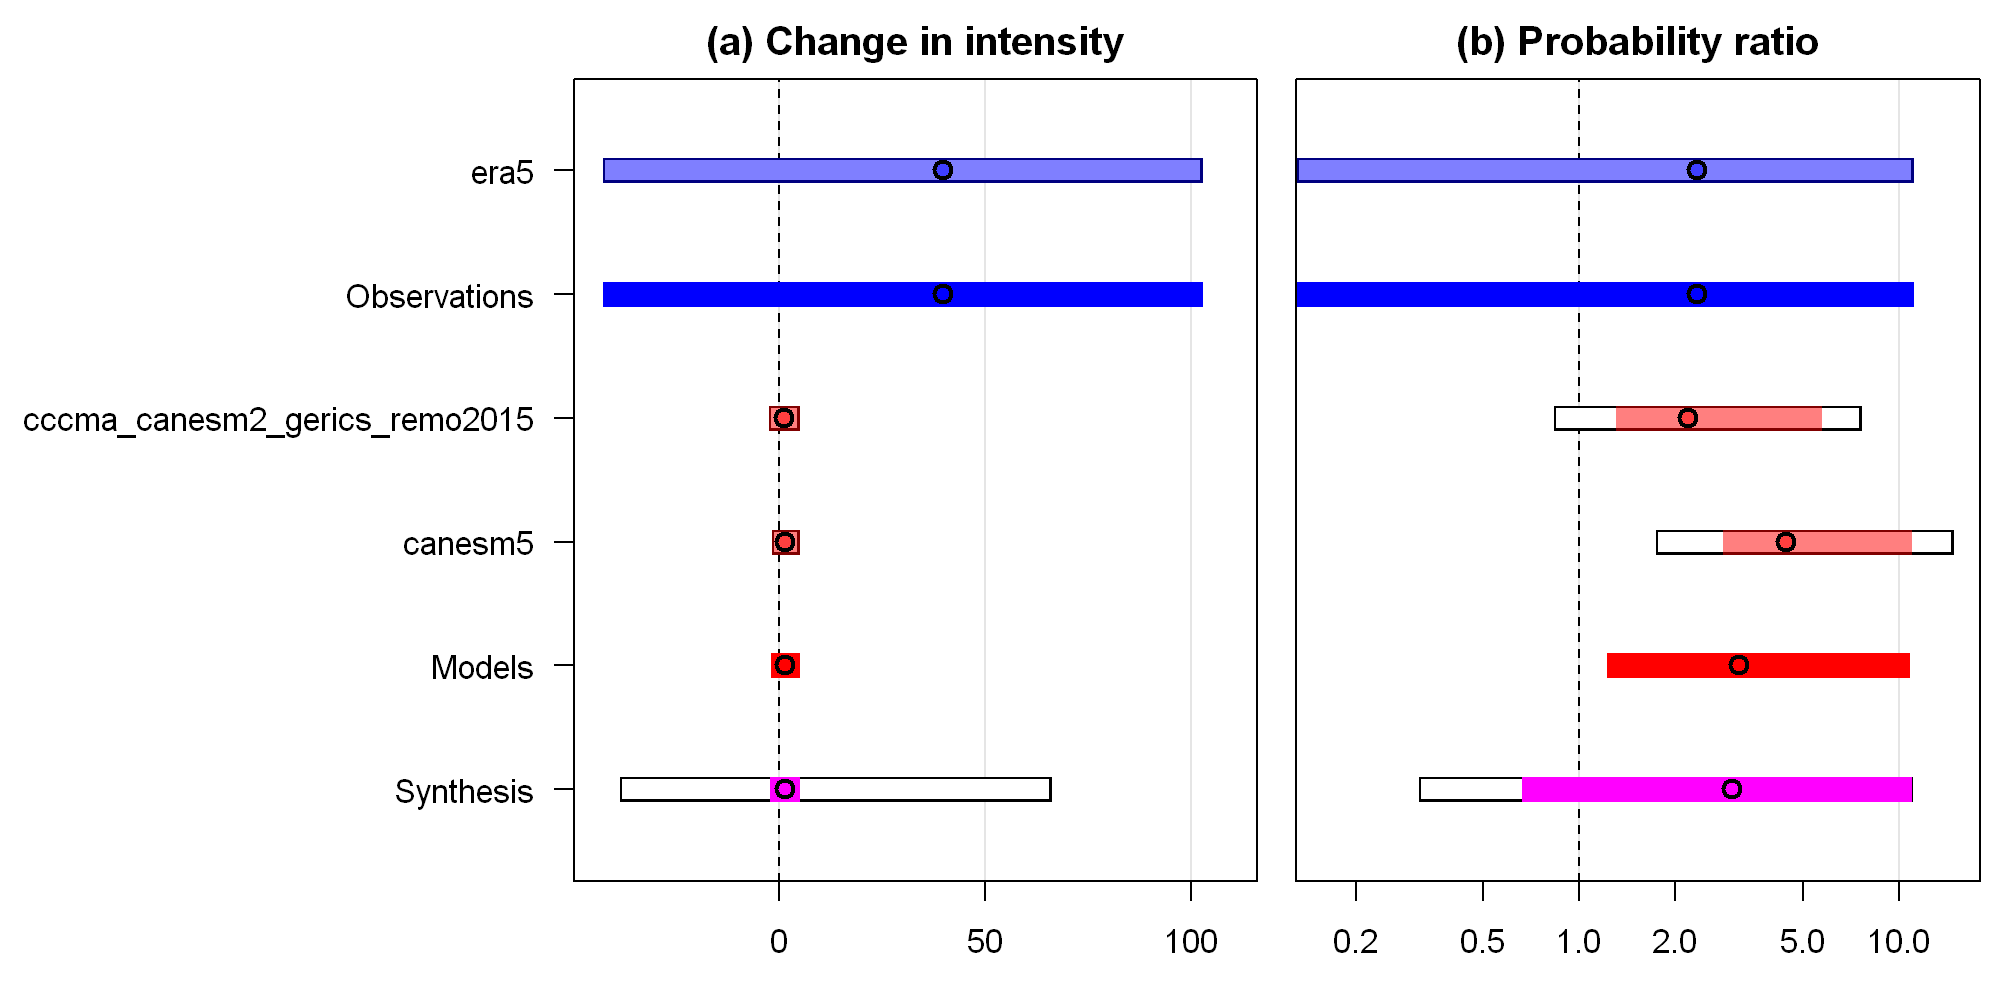

In [26]:
# put two figures next to each other
prep_window(prep_rc,
            h = prep_h,         # height of the figure (ins)
            w = prep_w,         # width of each panel (ins)
            res = prep_res,
            pch = prep_pch,
            oma = prep_oma,     # width of each panel (ins)
            mar = prep_mar)     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_attr, lwd=12, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
plot_synthesis(synth_PR_attr, lwd=12, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)

In [27]:
attr_export_path <- file.path(your_save_directory, "synth-fig_attr.png")

png(attr_export_path, height = 360, width = 480*1.5); par(mfrow = prep_rc, oma = prep_oma, mar = prep_mar); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
    plot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)
}; dev.off()

agg_record_2060987943 
                    2

In [28]:
prep_rc = c(1, 2)
prep_h = 5                      # height of the figure (ins)
prep_w = 5                      # width of the figure (ins)
prep_res = 200
prep_pch = 20
prep_oma = c(0, 14, 0, 0)       # increase second number until model names fit in margin
prep_mar = c(3, .5, 2, .5)      # shouldn't need to be changed

# Change until the bars fit the plot
x_lim_dI <- range(
  synth_dI_proj$df[sapply(synth_dI_proj$df, is.numeric)],
  na.rm = TRUE
) * 1.1
x_lim_PR = range(
  synth_PR_proj$df[sapply(synth_PR_proj$df, is.numeric)],
  na.rm = TRUE
) * 1.1 # add some padding to the x-axis limits

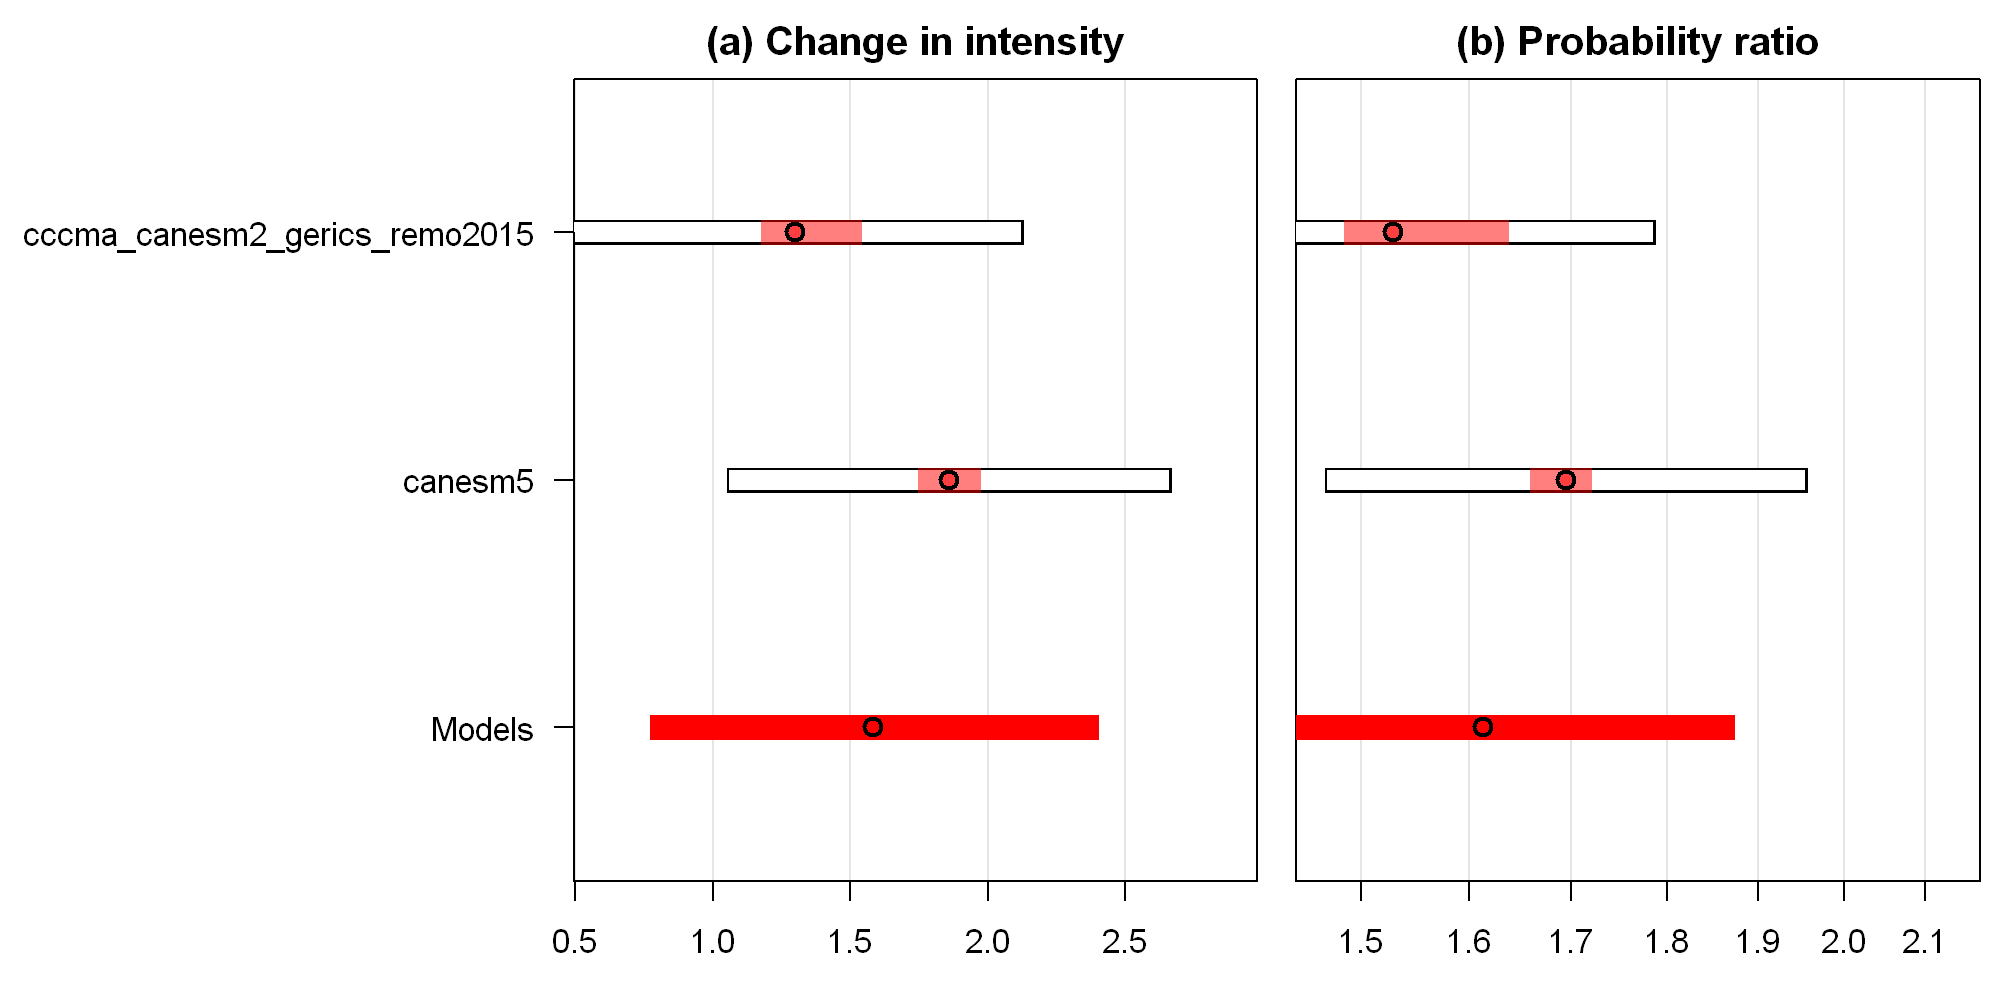

In [29]:
prep_window(prep_rc,
            h = prep_h,         # height of the figure (ins)
            w = prep_w,         # width of each panel (ins)
            res = prep_res,
            pch = prep_pch,
            oma = prep_oma,     # increase second number until model names fit in margin
            mar = prep_mar)     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_proj, lwd=12, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
plot_synthesis(synth_PR_proj, lwd=12, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)

In [30]:
proj_export_path <- file.path(your_save_directory, "synth-fig_proj.png")

png(proj_export_path, height = 240, width = 480*1.5); par(mfrow = prep_rc, oma = prep_oma, mar = prep_mar); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_proj, add_space = F, main = "(a) Change in intensity", xlim = x_lim_dI)
    plot_synthesis(synth_PR_proj, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = x_lim_PR)
}; dev.off()

agg_record_485579045 
                   2